In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import math
import copy
import numpy as np
import time
import matplotlib.pyplot as plt

# 封装随机种子函数，确保每次实验起跑线一致
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"当前运行设备: {DEVICE}")

当前运行设备: cuda


In [3]:
class VehicleDataset(Dataset):
    def __init__(self, img_paths, labels, transform=None):
        self.img_paths = img_paths
        self.labels = labels
        self.transform = transform
    def __len__(self): return len(self.img_paths)
    def __getitem__(self, idx):
        try:
            image = Image.open(self.img_paths[idx]).convert('RGB')
            if self.transform: image = self.transform(image)
            return image, self.labels[idx]
        except: return torch.zeros((3, 100, 100)), self.labels[idx]

def get_data_loaders(data_root, batch_size=16):
    """
    带数据增强的数据加载函数
    """
    # 1. 扫描尺寸并计算均值
    widths, heights = [], []
    valid_ext = ('.jpg', '.png', '.jpeg')
    for root, dirs, files in os.walk(data_root):
        for file in files:
            if file.lower().endswith(valid_ext):
                try:
                    with Image.open(os.path.join(root, file)) as img:
                        widths.append(img.width); heights.append(img.height)
                except: continue
    
    if not widths: raise ValueError("未找到图片")
    mean_w = math.ceil(sum(widths) / len(widths))
    mean_h = math.ceil(sum(heights) / len(heights))
    
    # 2. 定义 Transform 
    # 训练集：加入数据增强
    train_transform = transforms.Compose([
        transforms.Resize((mean_h, mean_w)),
        transforms.RandomHorizontalFlip(p=0.5), # 50%概率水平翻转
        transforms.RandomRotation(10),          # 随机旋转 -10 到 10 度
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # 颜色抖动
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
    
    # 测试集：仅做基础处理，不做增强
    test_transform = transforms.Compose([
        transforms.Resize((mean_h, mean_w)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
    
    # 3. 划分数据 
    classes = ['bus', 'car', 'truck']
    class_map = {n: i for i, n in enumerate(classes)}
    train_paths, train_lbls, test_paths, test_lbls = [], [], [], []
    
    for cls in classes:
        cls_dir = os.path.join(data_root, cls)
        if not os.path.exists(cls_dir): continue
        imgs = [os.path.join(cls_dir, x) for x in os.listdir(cls_dir) if x.lower().endswith(valid_ext)]
        np.random.shuffle(imgs)
        split = int(len(imgs) * 0.2)
        
        test_paths.extend(imgs[:split]); test_lbls.extend([class_map[cls]]*len(imgs[:split]))
        train_paths.extend(imgs[split:]); train_lbls.extend([class_map[cls]]*len(imgs[split:]))
    
    # 分别使用了 train_transform 和 test_transform
    train_ds = VehicleDataset(train_paths, train_lbls, train_transform)
    test_ds = VehicleDataset(test_paths, test_lbls, test_transform)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader, (mean_h, mean_w)


In [4]:
class DynamicCNN(nn.Module):
    def __init__(self, num_layers=2, kernel_size=3, num_classes=3, dropout_rate=0.5):
        super(DynamicCNN, self).__init__()
        
        layers = []
        in_channels = 3
        out_channels = 16
        
        # 动态构建卷积层
        for i in range(num_layers):
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, padding=kernel_size//2))
            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(2))
            
            in_channels = out_channels
            out_channels *= 2 
            
        self.features = nn.Sequential(*layers)
        
        self.final_channels = in_channels 
        
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        
        # 新增 Dropout 层
        self.dropout = nn.Dropout(p=dropout_rate)
        
        self.fc = nn.Linear(self.final_channels * 4 * 4, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = x.reshape(-1, self.final_channels * 4 * 4)
        
        # 在进入全连接层前应用 Dropout
        x = self.dropout(x)
        
        x = self.fc(x)
        return x

def train_model(model, train_loader, test_loader, lr=0.001, epochs=50, patience=5, device=DEVICE, name="Experiment"):
    """
    加入了早停机制的训练函数
    参数 patience: 容忍多少个 epoch 验证集 loss 不下降
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    history = {'loss': [], 'train_acc': [], 'test_acc': [], 'time': [], 'name': name}
    
    # 早停机制初始化
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
    patience_counter = 0
    
    print(f"\n开始实验: {name} | LR={lr} | Patience={patience}")
    start_time = time.time()
    
    for epoch in range(epochs):
        ep_start = time.time()
        
        # 1. 训练阶段
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total_train += lbls.size(0)
            correct_train += (preds == lbls).sum().item()
            
        # 2. 验证/测试阶段
        model.eval()
        correct_test = 0
        total_test = 0
        test_running_loss = 0.0 # 需要记录验证集的loss用于早停
        
        with torch.no_grad():
            for imgs, lbls in test_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, lbls) # 计算验证loss
                
                test_running_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                total_test += lbls.size(0)
                correct_test += (preds == lbls).sum().item()
        
        # 3. 统计指标
        avg_train_loss = running_loss / len(train_loader)
        avg_test_loss = test_running_loss / len(test_loader) # 计算平均验证loss
        
        train_acc = 100 * correct_train / total_train
        test_acc = 100 * correct_test / total_test
        ep_duration = time.time() - ep_start
        
        history['loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        history['time'].append(ep_duration)
        
        print(f"[{epoch+1}/{epochs}] Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Test Acc: {test_acc:.2f}%")
        
        # 4. 早停检查逻辑
        if avg_test_loss < best_loss:
            best_loss = avg_test_loss
            best_model_wts = copy.deepcopy(model.state_dict()) # 保存最佳模型权重
            patience_counter = 0 # 重置计数器
        else:
            patience_counter += 1 # 计数器+1
            
        if patience_counter >= patience:
            print(f"早停触发！在第 {epoch+1} 轮停止训练。最佳 Test Loss: {best_loss:.4f}")
            break
            
    total_time = time.time() - start_time
    print(f"实验 {name} 结束. 总耗时: {total_time:.2f}s")
    
    # 加载最佳模型权重
    model.load_state_dict(best_model_wts)
    return history

def plot_comparison(results_list):
    """
    输入: results_list = [history1, history2, ...]
    """
    # 修改画布大小为 18x10，以容纳两行图表
    plt.figure(figsize=(18, 10))
    
    # 1. 对比 Loss (左上)
    plt.subplot(2, 2, 1)
    for res in results_list:
        plt.plot(res['loss'], label=res['name'])
    plt.title('Loss Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 2. 对比 Test Accuracy (右上)
    plt.subplot(2, 2, 2)
    for res in results_list:
        plt.plot(res['test_acc'], label=res['name'])
    plt.title('Test Accuracy Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 3. 对比 训练总耗时 (左下 - 柱状图)
    plt.subplot(2, 2, 3)
    names = [res['name'] for res in results_list]
    times = [sum(res['time']) for res in results_list]
    bars = plt.bar(names, times, color=['skyblue', 'orange', 'lightgreen', 'pink'])
    plt.title('Total Training Time')
    plt.ylabel('Seconds')
    
    # 在柱子上标数值
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 1), ha='center', va='bottom')
        
    # 4. 对比 每一轮的耗时 (右下 - 分组柱状图) -- 新增部分
    plt.subplot(2, 2, 4)
    
    # 设置柱状图宽度和偏移量
    total_width = 0.8
    n_exp = len(results_list)
    bar_width = total_width / n_exp
    
    for i, res in enumerate(results_list):
        epoch_times = res['time']
        # 生成X轴坐标，使不同实验的柱子并排显示
        # 基础坐标是 1, 2, 3...，然后根据实验顺序进行偏移
        x_positions = np.arange(1, len(epoch_times) + 1) - (total_width / 2) + (i * bar_width) + (bar_width / 2)
        
        plt.bar(x_positions, epoch_times, width=bar_width, label=res['name'], alpha=0.7)

    plt.title('Time per Epoch Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Seconds')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('comparison_plot_with_epoch_time.png') # 保存图片
    plt.show()


开始实验: LR=0.1 | LR=0.1 | Patience=5
[1/50] Train Loss: 2.1454 | Test Loss: 0.9722 | Test Acc: 57.41%
[2/50] Train Loss: 0.9689 | Test Loss: 0.9506 | Test Acc: 57.78%
[3/50] Train Loss: 0.9601 | Test Loss: 0.9620 | Test Acc: 57.41%
[4/50] Train Loss: 0.9931 | Test Loss: 0.9634 | Test Acc: 57.41%
[5/50] Train Loss: 0.9544 | Test Loss: 0.9720 | Test Acc: 57.78%
[6/50] Train Loss: 0.9711 | Test Loss: 0.9718 | Test Acc: 57.41%
[7/50] Train Loss: 0.9625 | Test Loss: 0.9518 | Test Acc: 57.41%
早停触发！在第 7 轮停止训练。最佳 Test Loss: 0.9506
实验 LR=0.1 结束. 总耗时: 46.36s

开始实验: LR=0.01 | LR=0.01 | Patience=5
[1/50] Train Loss: 0.7751 | Test Loss: 0.5437 | Test Acc: 76.67%
[2/50] Train Loss: 0.6359 | Test Loss: 0.4999 | Test Acc: 82.22%
[3/50] Train Loss: 0.5875 | Test Loss: 0.4164 | Test Acc: 84.44%
[4/50] Train Loss: 0.5388 | Test Loss: 0.3675 | Test Acc: 85.93%
[5/50] Train Loss: 0.5002 | Test Loss: 0.3847 | Test Acc: 85.19%
[6/50] Train Loss: 0.4638 | Test Loss: 0.4121 | Test Acc: 82.96%
[7/50] Train Loss:

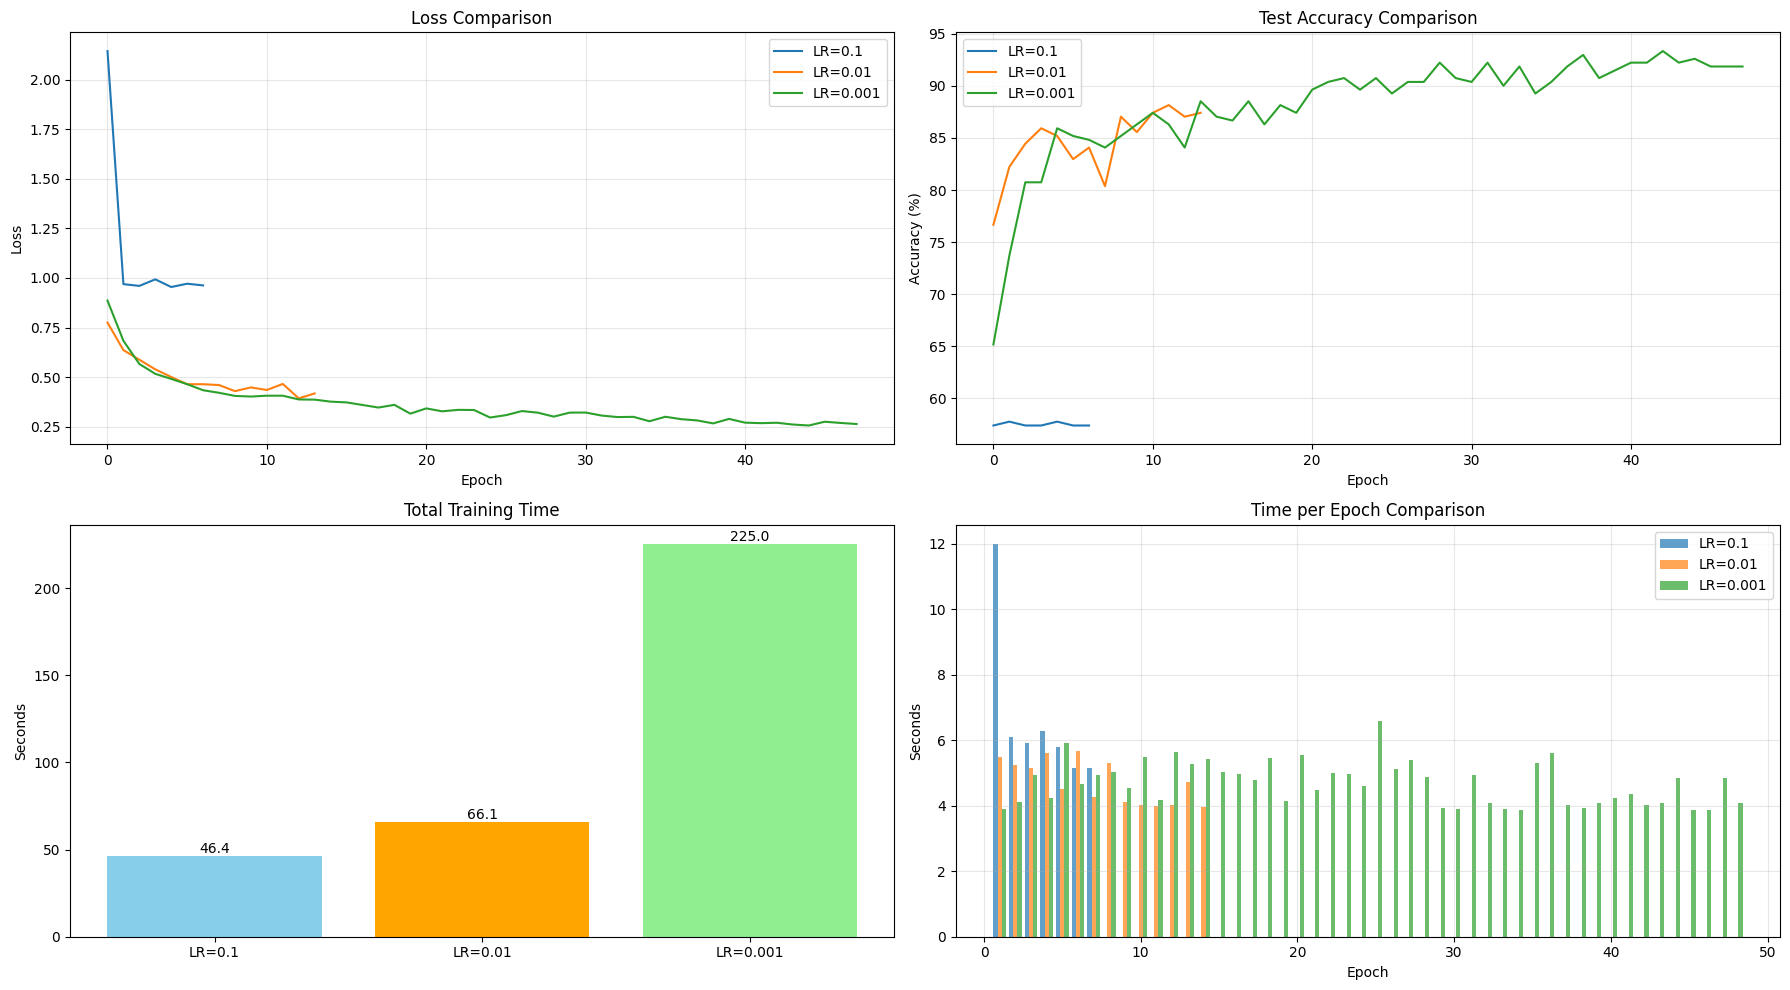

In [5]:
DATA_ROOT = './cardata'  
set_seed(42) 

train_loader, test_loader, _ = get_data_loaders(DATA_ROOT, batch_size=16)


model_1 = DynamicCNN(num_layers=2, kernel_size=3, dropout_rate=0.5)
hist_1 = train_model(model_1, train_loader, test_loader, lr=0.1, epochs=50, patience=5,name="LR=0.1")

set_seed(42) 
model_2 = DynamicCNN(num_layers=2, kernel_size=3, dropout_rate=0.5)
hist_2 = train_model(model_2, train_loader, test_loader, lr=0.01, epochs=50, patience=5, name="LR=0.01")
set_seed(42) 
model_3 = DynamicCNN(num_layers=2, kernel_size=3, dropout_rate=0.5)
hist_3 = train_model(model_3, train_loader, test_loader, lr=0.001, epochs=50, patience=5,name="LR=0.001")

# 4. 画图对比
plot_comparison([hist_1, hist_2, hist_3])

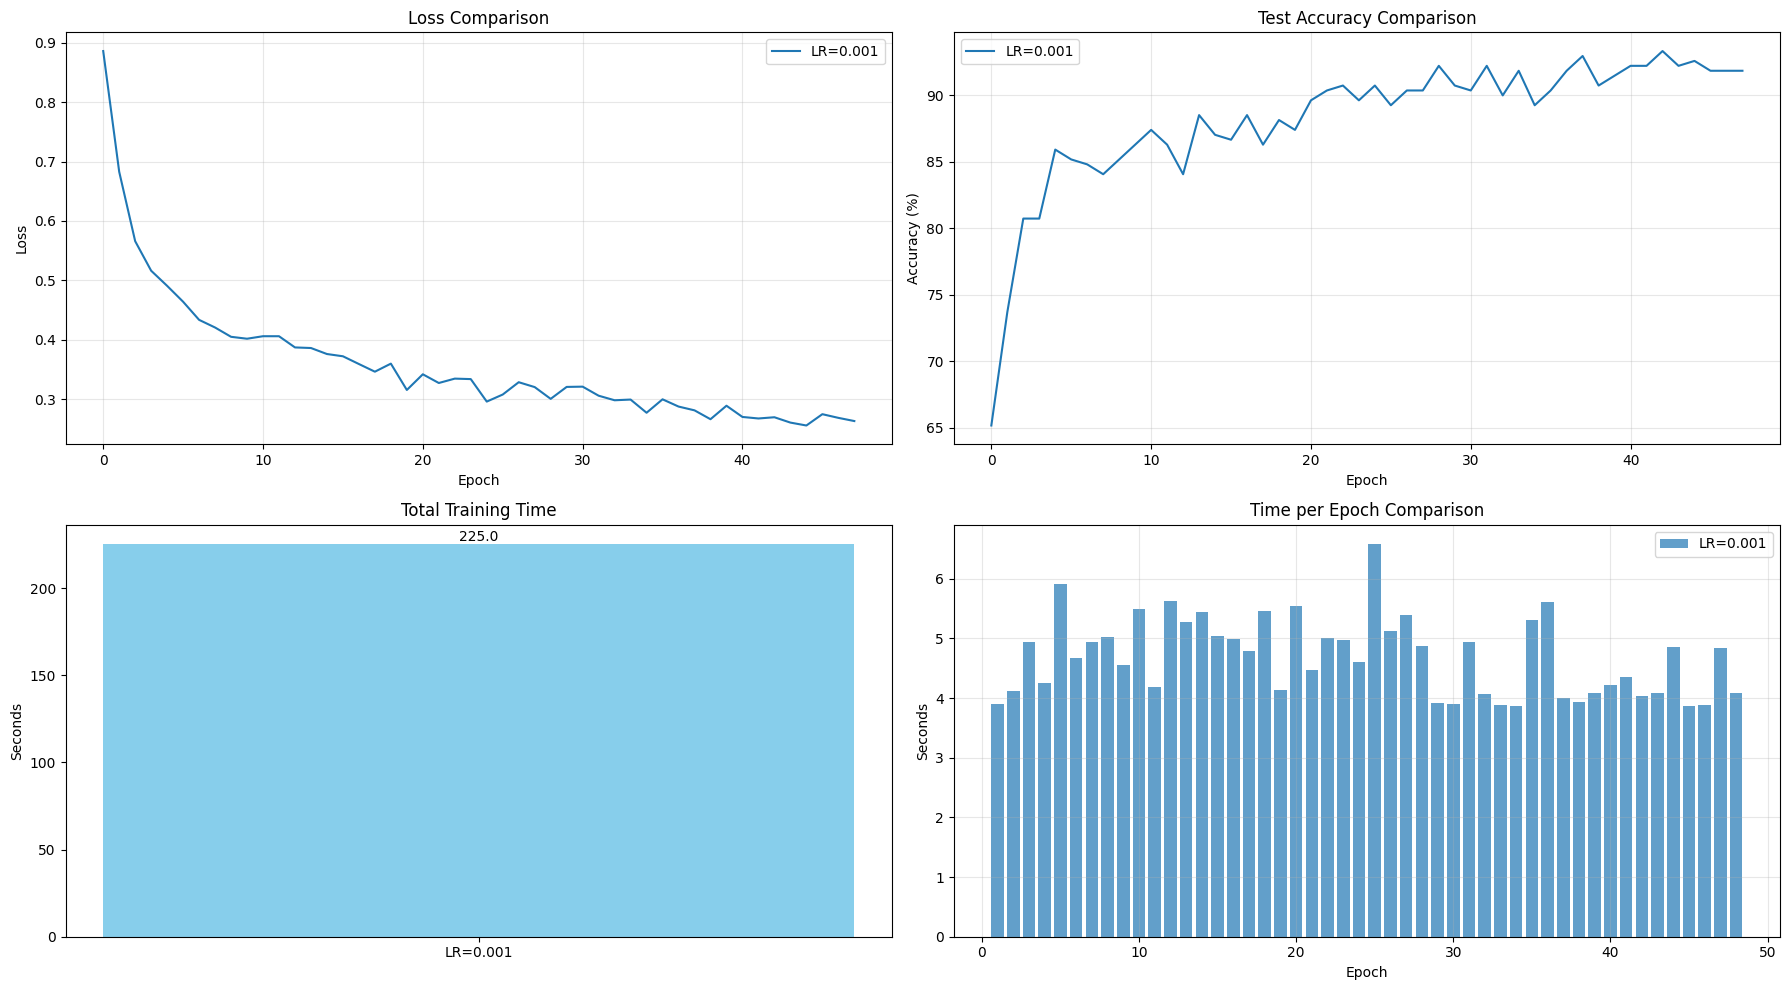

In [6]:
plot_comparison([hist_3])


开始实验: Layers=2 | LR=0.001 | Patience=5
[1/50] Train Loss: 0.8862 | Test Loss: 0.7160 | Test Acc: 65.19%
[2/50] Train Loss: 0.6828 | Test Loss: 0.5616 | Test Acc: 73.70%
[3/50] Train Loss: 0.5660 | Test Loss: 0.4951 | Test Acc: 80.74%
[4/50] Train Loss: 0.5162 | Test Loss: 0.4288 | Test Acc: 80.74%
[5/50] Train Loss: 0.4911 | Test Loss: 0.4109 | Test Acc: 85.56%
[6/50] Train Loss: 0.4642 | Test Loss: 0.3693 | Test Acc: 85.19%
[7/50] Train Loss: 0.4346 | Test Loss: 0.3573 | Test Acc: 84.81%
[8/50] Train Loss: 0.4203 | Test Loss: 0.3479 | Test Acc: 84.07%
[9/50] Train Loss: 0.4032 | Test Loss: 0.3285 | Test Acc: 85.56%
[10/50] Train Loss: 0.4017 | Test Loss: 0.3256 | Test Acc: 86.67%
[11/50] Train Loss: 0.4043 | Test Loss: 0.3210 | Test Acc: 87.78%
[12/50] Train Loss: 0.4047 | Test Loss: 0.3156 | Test Acc: 86.30%
[13/50] Train Loss: 0.3868 | Test Loss: 0.3236 | Test Acc: 84.44%
[14/50] Train Loss: 0.3847 | Test Loss: 0.3060 | Test Acc: 88.15%
[15/50] Train Loss: 0.3742 | Test Loss: 0.285

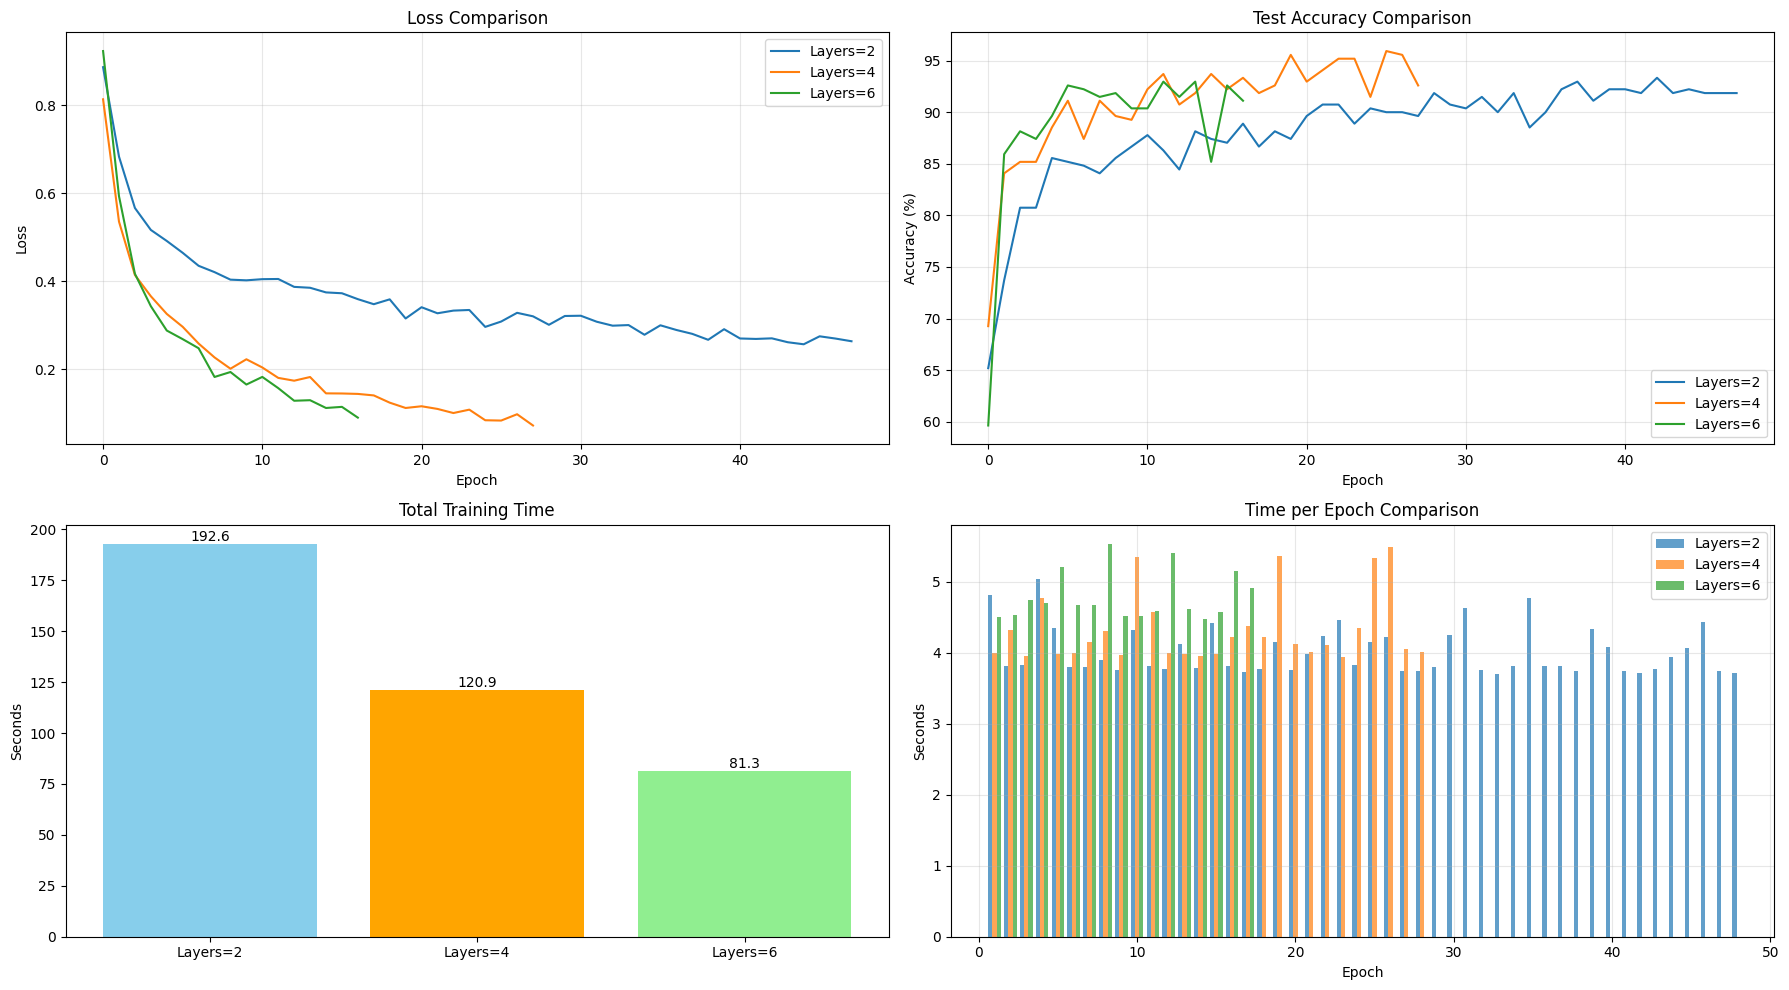

In [7]:
# 保持 Batch Size 和 LR 一致，只改变模型结构
train_loader, test_loader, _ = get_data_loaders(DATA_ROOT, batch_size=16)

# 实验 1: 浅层网络 (2层)
set_seed(42)
model_shallow = DynamicCNN(num_layers=2, kernel_size=3, dropout_rate=0.5)
hist_shallow = train_model(model_shallow, train_loader, test_loader, lr=0.001, epochs=50, patience=5, name="Layers=2")

# 实验 2: 深层网络 (4层)
set_seed(42)
model_med = DynamicCNN(num_layers=4, kernel_size=3, dropout_rate=0.5)
hist_med = train_model(model_med, train_loader, test_loader, lr=0.001, epochs=50, patience=5,name="Layers=4")

set_seed(42)
model_deep = DynamicCNN(num_layers=6, kernel_size=3, dropout_rate=0.5)
hist_deep = train_model(model_deep, train_loader, test_loader, lr=0.001, epochs=50, patience=5,name="Layers=6")

# 画图对比
plot_comparison([hist_shallow, hist_med, hist_deep])